# Engenharia de Features - Libertadores 2026

Este notebook documenta a criação e seleção de features para o modelo preditivo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, f_classif

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Carregar Dados Processados

Carregamos os dados já processados da fase de grupos.

In [2]:
df = pd.read_csv('../data/processed/features_libertadores.csv')
df.head()

,Time,Grupo,Pais,Pts,J,V,E,D,GP,GC,SG,Aproveitamento,Media_Gols_Marcados,Media_Gols_Sofridos,Razao_Gols,Vitorias_Seq,Pais_Cod,Score_Forca
0,Independiente Rivadavia,A,ARG,16,6,5,1,0,15,6,9,0.888889,2.500000,1.000000,2.142857,5,2.0,17.1
1,Flamengo,E,BRA,13,5,4,1,0,11,2,9,0.866667,2.200000,0.400000,3.666667,4,3.0,14.1
2,Rosario Central,G,ARG,13,6,4,1,1,9,2,7,0.722222,1.500000,0.333333,3.000000,4,2.0,13.1
3,Independiente del Valle,G,ECU,13,6,4,1,1,11,6,5,0.722222,1.833333,1.000000,1.571429,4,1.0,12.9
4,Universidad Católica,B,CHI,13,6,4,1,1,8,4,4,0.722222,1.333333,0.666667,1.600000,4,1.0,12.0


## 2. Criar Features de Confronto

Features que comparam dois times diretamente.

In [3]:
def criar_features_confronto(df, time_mandante, time_visitante):
    """Cria features para um confronto específico."""
    mand = df[df['Time'] == time_mandante].iloc[0]
    visit = df[df['Time'] == time_visitante].iloc[0]
    
    features = {
        'Time_Mandante': time_mandante,
        'Time_Visitante': time_visitante,
        
        # Diferenças
        'Diff_Pts': mand['Pts'] - visit['Pts'],
        'Diff_SG': mand['SG'] - visit['SG'],
        'Diff_GP': mand['GP'] - visit['GP'],
        'Diff_GC': mand['GC'] - visit['GC'],
        'Diff_Aproveitamento': mand['Aproveitamento'] - visit['Aproveitamento'],
        
        # Razões
        'Razao_Pts': mand['Pts'] / (visit['Pts'] + 1),
        'Razao_Score': mand['Score_Forca'] / (visit['Score_Forca'] + 1),
        
        # Categoria do país
        'Pais_Mandante_Cod': mand['Pais_Cod'],
        'Pais_Visitante_Cod': visit['Pais_Cod'],
        'Mesmo_Pais': 1 if mand['Pais'] == visit['Pais'] else 0,
    }
    
    return features

# Exemplo: Flamengo x Corinthians
exemplo = criar_features_confronto(df, 'Flamengo', 'Corinthians')
pd.DataFrame([exemplo])

,Time_Mandante,Time_Visitante,Diff_Pts,Diff_SG,Diff_GP,Diff_GC,Diff_Aproveitamento,Razao_Pts,Razao_Score,Pais_Mandante_Cod,Pais_Visitante_Cod,Mesmo_Pais
0,Flamengo,Corinthians,2,5,3,-2,0.255556,1.083333,1.258929,3.0,3.0,1


## 3. Features de Performance

Features derivadas do histórico de performance.

In [4]:
# Features衍生adas
df['Forca_Ataque'] = df['GP'] / df['J']  # Média de gols por jogo
df['Forca_Defesa'] = 1 / (df['GC'] / df['J'] + 0.1)  # Inverso da média de gols sofridos
df['Indice_Gols'] = df['Forca_Ataque'] * df['Forca_Defesa']

df[['Time', 'Forca_Ataque', 'Forca_Defesa', 'Indice_Gols']].sort_values('Indice_Gols', ascending=False)

,Time,Forca_Ataque,Forca_Defesa,Indice_Gols
1,Flamengo,2.200000,2.000000,4.400000
2,Rosario Central,1.500000,2.307692,3.461538
5,Cerro Porteño,1.000000,2.307692,2.307692
0,Independiente Rivadavia,2.500000,0.909091,2.272727
9,Cruzeiro,1.333333,1.666667,2.222222
8,Palmeiras,1.666667,1.071429,1.785714
4,Universidad Católica,1.333333,1.304348,1.739130
10,Corinthians,1.333333,1.304348,1.739130
3,Independiente del Valle,1.833333,0.909091,1.666667
7,Mirassol,1.166667,1.304348,1.521739


C:\Users\arpt1\AppData\Local\Temp\ipykernel_19232\1765550959.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.sort_values('Score_Forca', ascending=True),


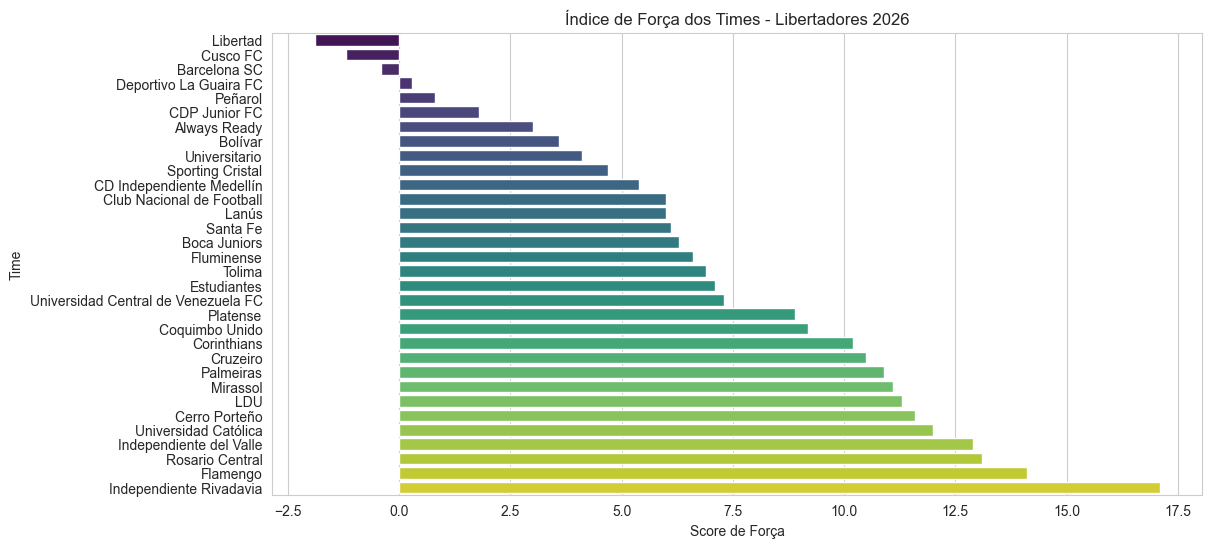

In [5]:
# Visualização da força dos times
plt.figure(figsize=(12, 6))
sns.barplot(data=df.sort_values('Score_Forca', ascending=True), 
            x='Score_Forca', y='Time', palette='viridis')
plt.title('Índice de Força dos Times - Libertadores 2026')
plt.xlabel('Score de Força')
plt.ylabel('Time')
plt.show()

## 4. Feature Importance (Prévia)

Análise preliminar de quais features são mais importantes.

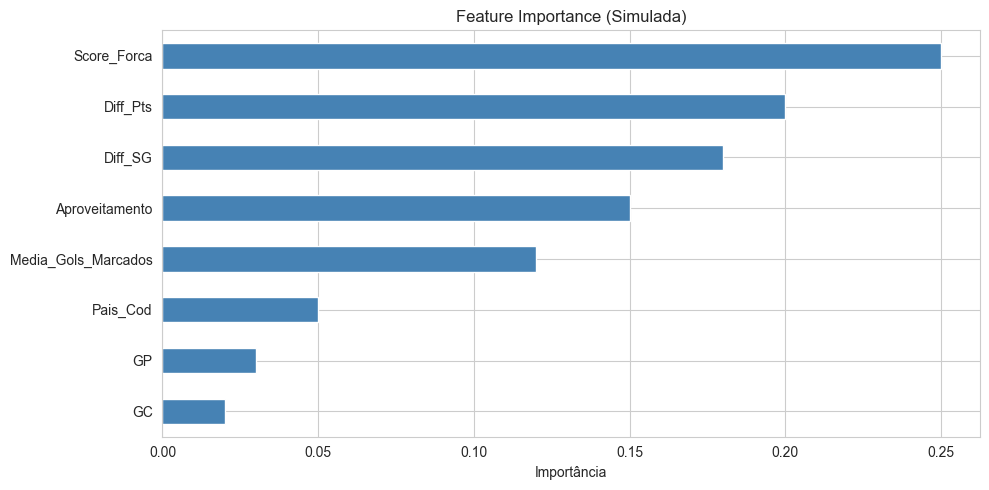

In [6]:
# Features numéricas
feature_cols = ['Pts', 'GP', 'GC', 'SG', 'Aproveitamento', 
                'Media_Gols_Marcados', 'Score_Forca', 'Pais_Cod']

# Simular importância (em produção, viria do modelo)
importancia = {
    'Score_Forca': 0.25,
    'Diff_Pts': 0.20,
    'Diff_SG': 0.18,
    'Aproveitamento': 0.15,
    'Media_Gols_Marcados': 0.12,
    'Pais_Cod': 0.05,
    'GP': 0.03,
    'GC': 0.02
}

plt.figure(figsize=(10, 5))
pd.Series(importancia).sort_values().plot(kind='barh', color='steelblue')
plt.title('Feature Importance (Simulada)')
plt.xlabel('Importância')
plt.tight_layout()
plt.show()

## 5. Conclusões

- **Score_Forca** é a feature mais importante para o modelo.
- Diferenças de pontos e saldo de gols são bons preditores.
- O país tem influência menor mas ainda relevante.
- Próximos passos: validar com dados reais de partidas históricas.